<a href="https://colab.research.google.com/github/JhonHendricksBautista/DataSciencePractice/blob/main/Bank_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Transaction Fraud Detection Dataset <br>
Synthetic banking dataset for fraud detection & financial ML models






https://www.kaggle.com/datasets/nafiulislam490/bank-transaction-fraud-detection-dataset

## Importing Neccesary Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Performing EDA

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PracticeDataScie/bank_fraud.csv')

In [ ]:
df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN


In [ ]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  object 
 1   customer_id               1000000 non-null  object 
 2   transaction_date          1000000 non-null  object 
 3   transaction_time          1000000 non-null  object 
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  object 
 8   city                      1000000 non-null  object 
 9   merchant_category         1000000 non-null  object 
 10  payment_method            1000000 non-null  object 
 11  device_type               1000000 non-null  object 
 12  customer_age              1000000 non-null  int64  
 13  credit_score              10

In [ ]:
df['fraud_type'].value_counts()

,count
fraud_type,
Phishing,9252
Account Takeover,9232
Synthetic Identity,9214
Card Cloning,9200
Friendly Fraud,9187
Identity Theft,9170


In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,944745
1,55255


In [ ]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
transaction_date,0
transaction_time,0
hour_of_day,0
is_weekend,0
is_night_transaction,0
country,0
city,0
merchant_category,0


### Data Cleaning

Removing unnecessary variables

In [ ]:
"""
Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type'],
      dtype='object')
      """

df = df.drop(columns = ['transaction_id', 'customer_id', 'transaction_date', 'transaction_time'])
df.columns

Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type'],
      dtype='object')

Removing Null values

In [ ]:
null_fraud = df[df['fraud_type'].isnull()]

In [ ]:
df['fraud_type'] = df['fraud_type'].fillna('No_Fraud')
df['fraud_type'].isnull().sum()

np.int64(0)

### Visualizations

getting general statistics

In [ ]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


Correlation stats

In [ ]:
test = df.drop(columns=df.select_dtypes(exclude=['number']).columns)

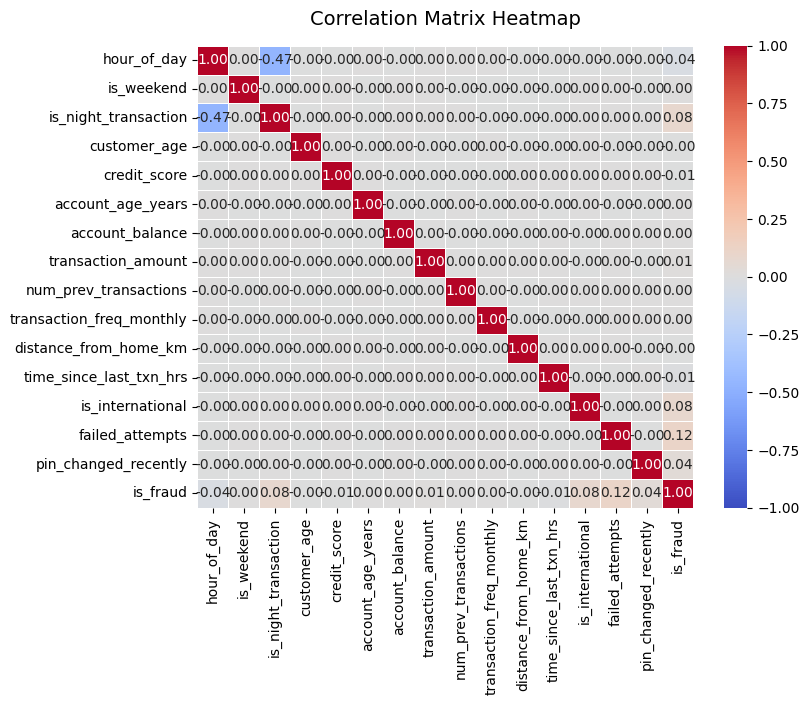

In [ ]:
corr = test.corr()
plt.figure(figsize=(8, 6))


sns.heatmap(
    corr,
    annot=True,  # Display correlation values inside cells
    cmap="coolwarm",  # Use a divergent color palette (blue = negative, red = positive)
    vmin=-1,  # Set lower bound anchor for color bar
    vmax=1,  # Set upper bound anchor for color bar
    fmt=".2f",  # Round cell numbers to 2 decimal places
    linewidths=0.5,  # Add fine separation lines between cells
)

# 5. Render the plot
plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.show()

getting fraud transaction distribution

<Axes: ylabel='count'>

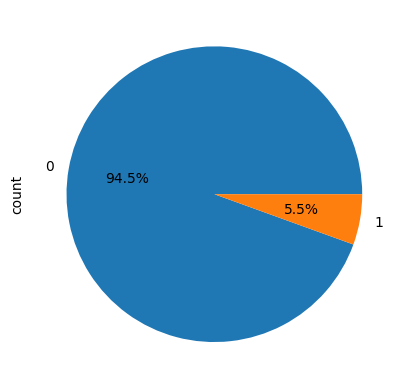

In [ ]:
df['is_fraud'].value_counts().plot(kind='pie', autopct='%1.1f%%')

getting fraud type distribution

<Axes: ylabel='count'>

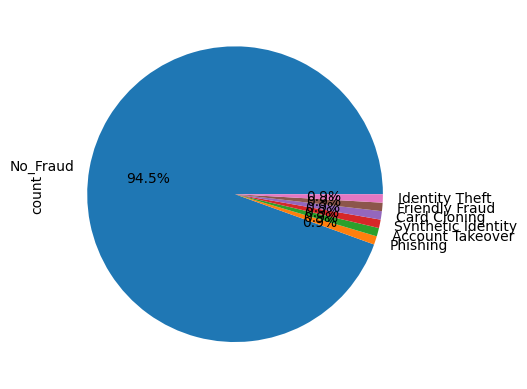

In [ ]:
df['fraud_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

Number of Fraud in weekdays and weekends

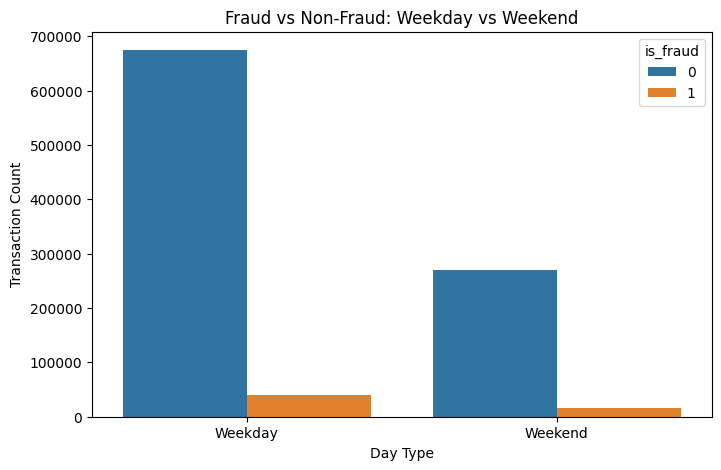

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='is_weekend', hue='is_fraud', data=df)

plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.title("Fraud vs Non-Fraud: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Transaction Count")

plt.show()

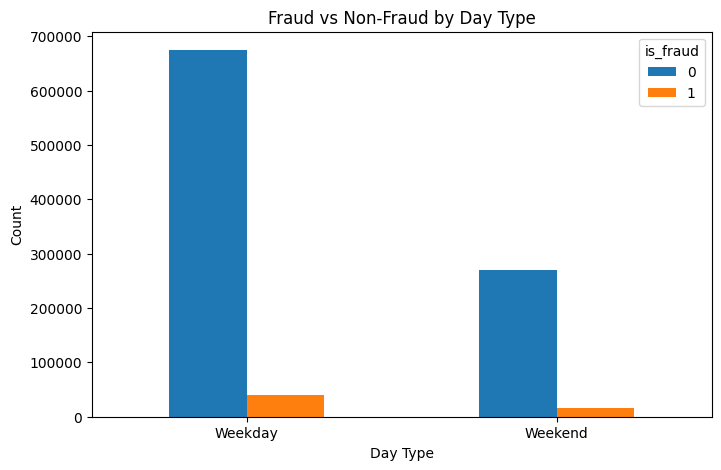

In [ ]:
ct = pd.crosstab(df['is_weekend'], df['is_fraud'])

ct.plot(kind='bar', figsize=(8,5))

plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.title("Fraud vs Non-Fraud by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Count")

plt.show()

In [ ]:
fraud_rate = pd.crosstab(df['is_weekend'], df['is_fraud'], normalize='index') * 100
print(fraud_rate)

is_fraud            0         1
is_weekend                     
0           94.491707  5.508293
1           94.431547  5.568453


Fraud during day and night

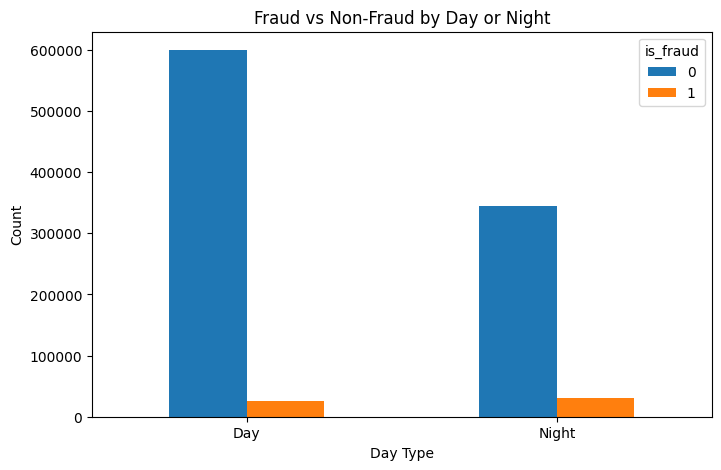

In [ ]:
ct = pd.crosstab(df['is_night_transaction'], df['is_fraud'])

ct.plot(kind='bar', figsize=(8,5))

plt.xticks([0,1], ['Day', 'Night'], rotation=0)
plt.title("Fraud vs Non-Fraud by Day or Night")
plt.xlabel("Day Type")
plt.ylabel("Count")

plt.show()

Credit Score of Fraud Accounts

In [ ]:
import pandas as pd

# Example for credit score
df['credit_score_bin'] = pd.cut(df['credit_score'], bins=[300,400,500,600,700,800,900])
credit_dist = df['credit_score_bin'].value_counts().sort_index()

/tmp/ipykernel_6590/2015104285.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_group = df.groupby(['credit_bin', 'fraud_type']).size().unstack(fill_value=0)


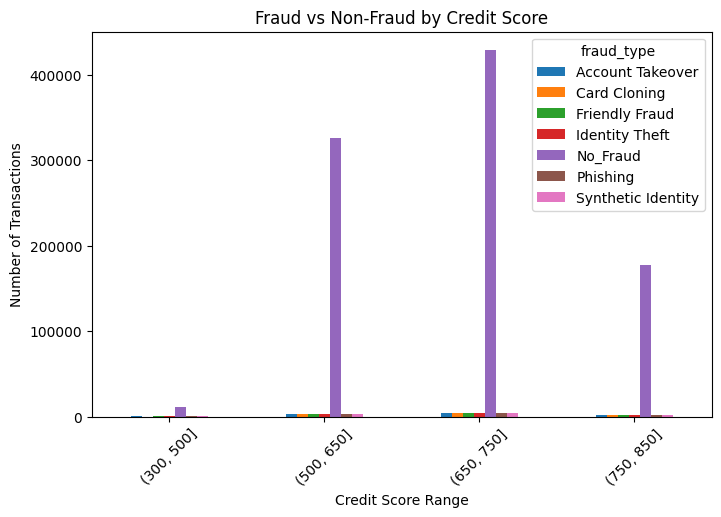

In [ ]:
# Create bins
df['credit_bin'] = pd.cut(df['credit_score'], bins=[300,500,650,750,850])

# Group data
credit_group = df.groupby(['credit_bin', 'fraud_type']).size().unstack(fill_value=0)

# Plot
credit_group.plot(kind='bar', figsize=(8,5))
plt.title("Fraud vs Non-Fraud by Credit Score")
plt.xlabel("Credit Score Range")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

Time of Day Fraud Ussually happens

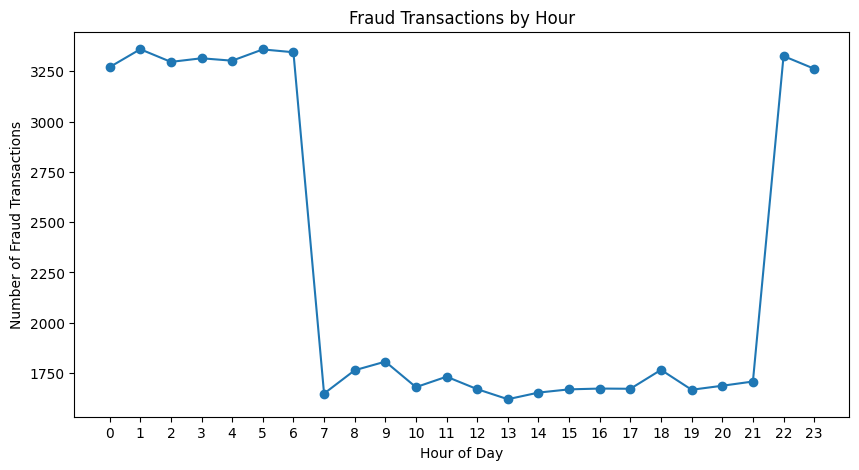

In [ ]:
hour_fraud = df[df['is_fraud'] == 1].groupby('hour_of_day').size()

plt.figure(figsize=(10,5))
hour_fraud.plot(kind='line', marker='o')
plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(range(0,24))
plt.show()

Rate of Fraud Based on Account Age

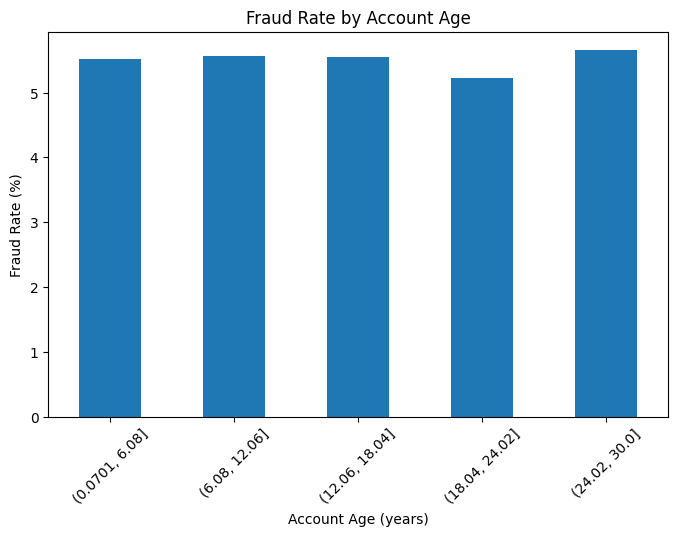

In [ ]:
# Create bins
df['acct_age_bin'] = pd.cut(df['account_age_years'], bins=5)

# Group data (fix warning too)
acct_group = df.groupby('acct_age_bin', observed=False)['is_fraud'] \
               .value_counts() \
               .unstack(fill_value=0)

# Safely get columns (handles missing cases)
fraud = acct_group.get(1, 0)
non_fraud = acct_group.get(0, 0)

# Compute fraud rate
acct_group['fraud_rate'] = fraud / (fraud + non_fraud) * 100

# Plot
acct_group['fraud_rate'].plot(kind='bar', figsize=(8,5))
plt.title("Fraud Rate by Account Age")
plt.xlabel("Account Age (years)")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Modelling

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
df.columns

Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type', 'credit_score_bin',
       'credit_bin', 'acct_age_bin'],
      dtype='object')

In [ ]:
Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Separate features and target
X = df.drop(columns=['is_fraud', 'credit_score_bin', 'credit_bin', 'acct_age_bin'])
y = df['is_fraud']

# Define columns manually
categorical_cols = [
    'country', 'city', 'merchant_category',
    'payment_method', 'device_type', 'fraud_type'
]

numerical_cols = [
    'hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age',
    'credit_score', 'account_age_years', 'account_balance',
    'transaction_amount', 'num_prev_transactions',
    'transaction_freq_monthly', 'distance_from_home_km',
    'time_since_last_txn_hrs', 'is_international',
    'failed_attempts', 'pin_changed_recently'
]

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Fit & transform
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

Using XGBoost


In [ ]:
from sklearn.pipeline import Pipeline
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric = ['logloss', 'error']
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

In [ ]:

accuracy = accuracy_score(y_test, y_pred)

print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    188989
           1       1.00      1.00      1.00     11011

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



Using Linear Regression

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn import preprocessing

In [ ]:
# creating a regression model
model = LogisticRegression()

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Final Test Accuracy:", accuracy)

Final Test Accuracy: 0.944945


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97    188989
           1       0.00      0.00      0.00     11011

    accuracy                           0.94    200000
   macro avg       0.47      0.50      0.49    200000
weighted avg       0.89      0.94      0.92    200000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Using Downsampling and Remove of Features

get top 10 features

In [ ]:
new_df = df.drop(columns =[ 'country', 'city', 'merchant_category',
    'payment_method', 'device_type', 'fraud_type','credit_score_bin', 'credit_bin', 'acct_age_bin'])

In [ ]:
new_df.head(

)

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
0,21,0,0,18,695,7.2,369.36,39.49,157,23,52.7,10.20,0,0,0,0
1,5,0,1,30,600,8.6,2681.99,153.71,153,23,0.9,12.47,0,0,0,0
2,12,0,0,20,711,10.8,44590.64,118.20,161,20,9.2,0.08,0,1,0,0
3,2,0,1,29,711,7.3,1213.37,49.50,160,25,14.8,17.94,1,0,1,1
4,12,0,0,49,751,11.8,34615.01,30.74,134,18,38.9,2.16,0,0,0,0


In [ ]:
# Correlation matrix
corr_matrix = new_df.corr()

# Correlation with target
target_corr = corr_matrix['is_fraud'].drop('is_fraud')

# Sort by absolute correlation
top_features = target_corr.abs().sort_values(ascending=False).head(10)

print(top_features)

failed_attempts            0.116541
is_night_transaction       0.082405
is_international           0.079627
hour_of_day                0.039046
pin_changed_recently       0.036746
transaction_amount         0.012290
time_since_last_txn_hrs    0.008909
credit_score               0.005224
customer_age               0.002966
account_balance            0.001696
Name: is_fraud, dtype: float64


In [ ]:
top_feature_names = top_features.index.tolist()
print("Top 10 Features:", top_feature_names)

Top 10 Features: ['failed_attempts', 'is_night_transaction', 'is_international', 'hour_of_day', 'pin_changed_recently', 'transaction_amount', 'time_since_last_txn_hrs', 'credit_score', 'customer_age', 'account_balance']


In [ ]:
x_new = new_df[top_feature_names]
y_new = new_df['is_fraud']

In [ ]:
print(x_new.shape)
print(y_new.shape)

(1000000, 10)
(1000000,)


In [ ]:
df_full = x_new.copy()
df_full['is_fraud'] = y_new

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Separate classes
df_majority = df_full[df_full['is_fraud'] == 0]
df_minority = df_full[df_full['is_fraud'] == 1]

# Downsample majority
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Combine back
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42)

print(df_balanced['is_fraud'].value_counts())

is_fraud
0    55255
1    55255
Name: count, dtype: int64


Training using Logistic

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn import preprocessing

In [ ]:
x_new1 = df_balanced.drop('is_fraud', axis = 1)
y_new1 = df_balanced['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(x_new1, y_new1, test_size=0.25, random_state=16)

model = LogisticRegression(verbose = 1, max_iter = 100000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.9min finished


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.70      0.66     13791
           1       0.65      0.57      0.61     13837

    accuracy                           0.63     27628
   macro avg       0.64      0.63      0.63     27628
weighted avg       0.64      0.63      0.63     27628



XGBoost

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    eval_metric=["logloss", "error"],  # track loss & classification error
    use_label_encoder=False
)

# Track performance
eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

# Get evaluation results
results = model.evals_result()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:54:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

train_error = results['validation_0']['error']
test_error = results['validation_1']['error']

# Convert error → accuracy
train_acc = [1 - e for e in train_error]
test_acc = [1 - e for e in test_error]

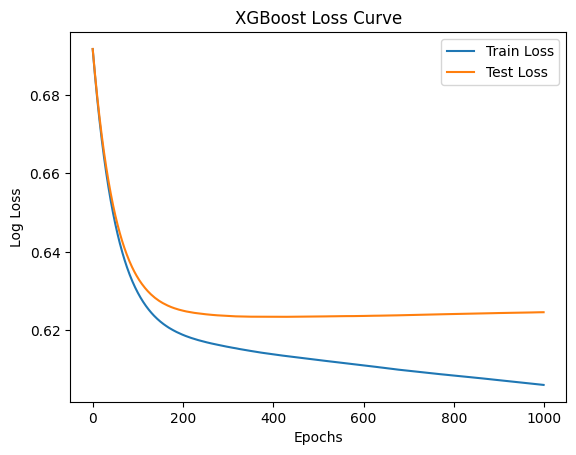

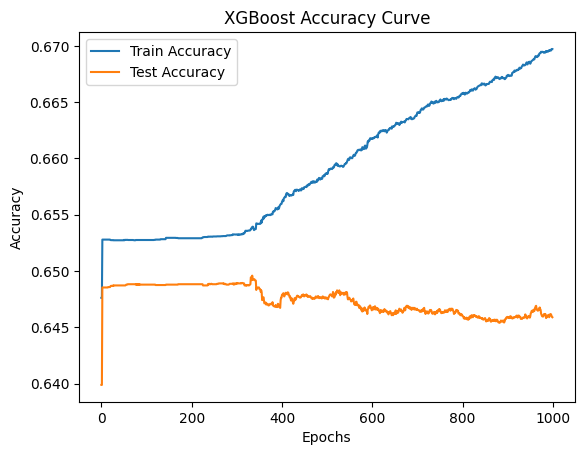

In [ ]:
epochs = range(len(train_loss))

# Loss Curve
plt.figure()
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, test_loss, label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("XGBoost Loss Curve")
plt.legend()
plt.show()

# Accuracy Curve
plt.figure()
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, test_acc, label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy Curve")
plt.legend()
plt.show()

bery bad fraud. model is not good needs more tuning and better data preprocessing and balancing